# 07 — Evaluación adversarial del modelo v2 con IBM ART

**Objetivo**: cuantificar la robustez del **RF v2** y del **XGBoost v2**
frente a ataques de evasión black-box. El detector se entrena asumiendo
que las features llegan "honestas"; acá medimos qué pasa cuando un
atacante perturba esas features con el mínimo necesario para eludir la
detección.

**Inputs**:
- `models/rf_multiclass_v2.joblib`, `xgb_multiclass_v2.joblib`,
  `scaler_v2.joblib`, `label_encoder_v2.joblib` (cargados por hash).
- `datasets/cicids_test.parquet` para sacar muestras de cada clase.

**Output** (gitignored): `logs/art_evasion_v2.json` con tasas de evasión
y perturbación L2 promedio.

---

## Threat model

- **Acceso al modelo**: black-box. El atacante NO tiene los pesos, solo
  puede consultar la API y ver la predicción.
- **Capacidad**: modificar features de un flujo (espacio de features,
  no espacio de tráfico real — ver caveats al final).
- **Métrica de éxito**: reclasificación de un ataque como `Benign` con
  perturbación mínima.
- **Algoritmo**: HopSkipJump (Chen et al. 2020), L2-norm minimization.

## Por qué importa

Un F1-macro alto NO implica robustez. Si el atacante puede generar
adversarials con perturbación pequeña, el modelo es frágil aunque sus
métricas en datos limpios sean buenas. Esto **justifica la
complementariedad ML + Suricata**: las firmas siguen disparando aunque
el ML caiga.

In [1]:
import os
import json
import hashlib
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from art.attacks.evasion import HopSkipJump
from art.estimators.classification import SklearnClassifier, XGBoostClassifier

pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid', palette='muted')

MODELS_DIR   = os.path.abspath(os.path.join(os.getcwd(), '..', 'models'))
DATASETS_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', 'datasets'))
LOGS_DIR     = os.path.abspath(os.path.join(os.getcwd(), '..', 'logs'))
os.makedirs(LOGS_DIR, exist_ok=True)
DATA_PATH = os.path.join(DATASETS_DIR, 'cicids_test.parquet')
RESULT_PATH = os.path.join(LOGS_DIR, 'art_evasion_v2.json')
print(f"MODELS_DIR  = {MODELS_DIR}")
print(f"DATA_PATH   = {DATA_PATH}")
print(f"RESULT_PATH = {RESULT_PATH}")

/var/data/python/lib/python3.13/site-packages/art/estimators/certification/__init__.py:30: UserWarning: PyTorch not found. Not importing DeepZ or Interval Bound Propagation functionality
  warnings.warn("PyTorch not found. Not importing DeepZ or Interval Bound Propagation functionality")


MODELS_DIR  = /run/media/keppler-exe/KINGSTON/Laboratorio-MLCyber/models
DATA_PATH   = /run/media/keppler-exe/KINGSTON/Laboratorio-MLCyber/datasets/cicids_test.parquet
RESULT_PATH = /run/media/keppler-exe/KINGSTON/Laboratorio-MLCyber/logs/art_evasion_v2.json


## 1. Carga de artefactos v2 con verificación de hash

Replicamos el procedimiento del ML API: leemos `manifest.json` (que
ahora apunta a v2 tras la promoción), verificamos cada SHA-256, y solo
después cargamos.

In [2]:
def sha256_of(path):
    h = hashlib.sha256()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(1024*1024), b''):
            h.update(chunk)
    return h.hexdigest()

def safe_load(name):
    path = os.path.join(MODELS_DIR, name)
    expected = manifest[name]
    actual = sha256_of(path)
    assert actual == expected, f"Hash mismatch en {name}: {actual[:12]} vs {expected[:12]}"
    return joblib.load(path)

manifest = json.load(open(os.path.join(MODELS_DIR, 'manifest.json')))
print(f"Manifest activo: {len(manifest)} artefactos\n")

rf_multi      = safe_load('rf_multiclass_v2.joblib')
xgb_multi     = safe_load('xgb_multiclass_v2.joblib')
scaler        = safe_load('scaler_v2.joblib')
label_encoder = safe_load('label_encoder_v2.joblib')
feature_names = safe_load('feature_names_v2.joblib')
classes = list(label_encoder.classes_)
print(f"Categorías: {classes}")
print(f"Features: {len(feature_names)}")

Manifest activo: 7 artefactos

Categorías: ['Benign', 'Brute Force', 'DDoS', 'DoS', 'Reconnaissance', 'Web Attack']
Features: 47


sh: line 1: nvidia-smi: command not found


## 2. Sampling de flujos de ataque

Tomamos **5 muestras por categoría de ataque** del parquet bundleado.
HopSkipJump es caro (~30s por muestra en black-box), así que mantenemos
N chico para que el notebook se ejecute en minutos.

In [3]:
df = pd.read_parquet(DATA_PATH)
print(f"Dataset: {df.shape}")
print(f"Por clase: {df['Label_6'].value_counts().to_dict()}")

# Tomar solo categorías de ataque (no Benign) — esas son las que queremos evadir
attack_classes = [c for c in classes if c != 'Benign']
N_PER_CLASS = 5

samples = []
for cat in attack_classes:
    grp = df[df['Label_6'] == cat]
    if len(grp) < N_PER_CLASS:
        continue
    samples.append(grp.sample(n=N_PER_CLASS, random_state=42))
attack_df = pd.concat(samples, ignore_index=True)
print(f"\nMuestras para ataque adversarial: {attack_df.shape}")
print(f"Por clase: {attack_df['Label_6'].value_counts().to_dict()}")

X_attack = attack_df[feature_names].values.astype(np.float32)
y_attack_str = attack_df['Label_6'].values
y_attack = label_encoder.transform(y_attack_str)
print(f"\nX_attack shape: {X_attack.shape}")

Dataset: (12000, 48)
Por clase: {'Benign': 2000, 'DoS': 2000, 'Reconnaissance': 2000, 'DDoS': 2000, 'Brute Force': 2000, 'Web Attack': 2000}

Muestras para ataque adversarial: (25, 48)
Por clase: {'Brute Force': 5, 'DDoS': 5, 'DoS': 5, 'Reconnaissance': 5, 'Web Attack': 5}

X_attack shape: (25, 47)


## 3. Predicción limpia (baseline)

Antes de atacar, confirmamos que el modelo clasifica BIEN estos flujos
(de lo contrario, "evasión" no significaría nada — ya estaban mal
clasificados).

In [4]:
def report_clean(model, name, X, y_true_str):
    pred = model.predict(X)
    pred_str = label_encoder.inverse_transform(pred)
    correct = (pred_str == y_true_str)
    pct = correct.mean() * 100
    print(f"  {name}: clasifica correcto {correct.sum()}/{len(X)} ({pct:.1f}%)")
    return correct, pred

print("Predicción limpia (sin perturbación):")
correct_rf, pred_rf_clean = report_clean(rf_multi, 'RF v2', X_attack, y_attack_str)
correct_xgb, pred_xgb_clean = report_clean(xgb_multi, 'XGBoost v2', X_attack, y_attack_str)

Predicción limpia (sin perturbación):
  RF v2: clasifica correcto 24/25 (96.0%)
  XGBoost v2: clasifica correcto 25/25 (100.0%)


## 4. Ataque HopSkipJump contra RF v2

Solo atacamos las muestras que el modelo clasifica **correctamente**
(no tiene sentido evadir algo ya mal predicho).

In [5]:
def run_hsj(model, name, X, y_true, mask_correct):
    X_correct = X[mask_correct]
    y_correct = y_true[mask_correct]
    print(f"\n=== {name} ===")
    print(f"Atacando {len(X_correct)} muestras correctamente clasificadas...")

    import xgboost as xgb_lib
    if isinstance(model, xgb_lib.XGBClassifier):
        art_clf = XGBoostClassifier(
            model=model, clip_values=(X.min(), X.max()),
            nb_features=X.shape[1], nb_classes=len(classes),
        )
    else:
        art_clf = SklearnClassifier(model=model, clip_values=(X.min(), X.max()))

    # Targeted=False: el atacante quiere que se reclasifique a CUALQUIER otra
    # clase (en este caso, idealmente Benign). HopSkipJump untargeted busca
    # la mínima perturbación que cambie la decisión.
    attack = HopSkipJump(
        classifier=art_clf,
        targeted=False,
        norm=2,
        max_iter=20,
        max_eval=300,
        init_eval=20,
        verbose=False,
    )

    X_adv = attack.generate(X_correct)
    pred_adv = model.predict(X_adv)
    pred_adv_str = label_encoder.inverse_transform(pred_adv)

    # Cuántas evadieron (predicción ≠ true class)
    evaded = pred_adv != y_correct
    benign_evade = pred_adv_str == 'Benign'
    l2_dist = np.linalg.norm(X_adv - X_correct, axis=1)

    print(f"  Evasión total (cualquier clase ≠ original): {evaded.sum()}/{len(X_adv)} ({evaded.mean()*100:.1f}%)")
    print(f"  Evasión a Benign:                            {benign_evade.sum()}/{len(X_adv)} ({benign_evade.mean()*100:.1f}%)")
    print(f"  L2 promedio: {l2_dist.mean():.4f}  | mediana: {np.median(l2_dist):.4f}")

    return {
        'name': name,
        'n_attacked': int(len(X_adv)),
        'evasion_rate': float(evaded.mean()),
        'benign_evasion_rate': float(benign_evade.mean()),
        'l2_mean': float(l2_dist.mean()),
        'l2_median': float(np.median(l2_dist)),
        'l2_min':  float(l2_dist.min()),
        'l2_max':  float(l2_dist.max()),
        'X_adv': X_adv,
        'pred_adv_str': pred_adv_str,
        'l2_per_sample': l2_dist.tolist(),
        'true_str': label_encoder.inverse_transform(y_correct).tolist(),
    }

results_rf = run_hsj(rf_multi, 'RF v2', X_attack, y_attack, correct_rf)


=== RF v2 ===
Atacando 24 muestras correctamente clasificadas...


  Evasión total (cualquier clase ≠ original): 24/24 (100.0%)
  Evasión a Benign:                            21/24 (87.5%)
  L2 promedio: 134.3180  | mediana: 2.6289


## 5. Ataque HopSkipJump contra XGBoost v2

In [6]:
results_xgb = run_hsj(xgb_multi, 'XGBoost v2', X_attack, y_attack, correct_xgb)


=== XGBoost v2 ===
Atacando 25 muestras correctamente clasificadas...


  Evasión total (cualquier clase ≠ original): 25/25 (100.0%)
  Evasión a Benign:                            19/25 (76.0%)
  L2 promedio: 13.8798  | mediana: 2.6682


## 6. Comparativa de robustez

| Métrica | Significado |
|---|---|
| `evasion_rate` | % de muestras que cambiaron de clase tras la perturbación |
| `benign_evasion_rate` | % que pasaron específicamente a `Benign` (escenario peor caso) |
| `l2_mean` | Magnitud de perturbación promedio en distancia euclidiana |

**Más robusto** = menor evasion_rate o L2 más alto requerido.

In [7]:
comp = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ('X_adv', 'pred_adv_str', 'l2_per_sample', 'true_str')}
    for r in [results_rf, results_xgb]
])
print("Comparativa de robustez:")
comp

Comparativa de robustez:


,name,n_attacked,evasion_rate,benign_evasion_rate,l2_mean,l2_median,l2_min,l2_max
0,RF v2,24,1.0,0.875,134.318039,2.628890,0.816157,1320.853394
1,XGBoost v2,25,1.0,0.760,13.879825,2.668238,0.000017,100.852051


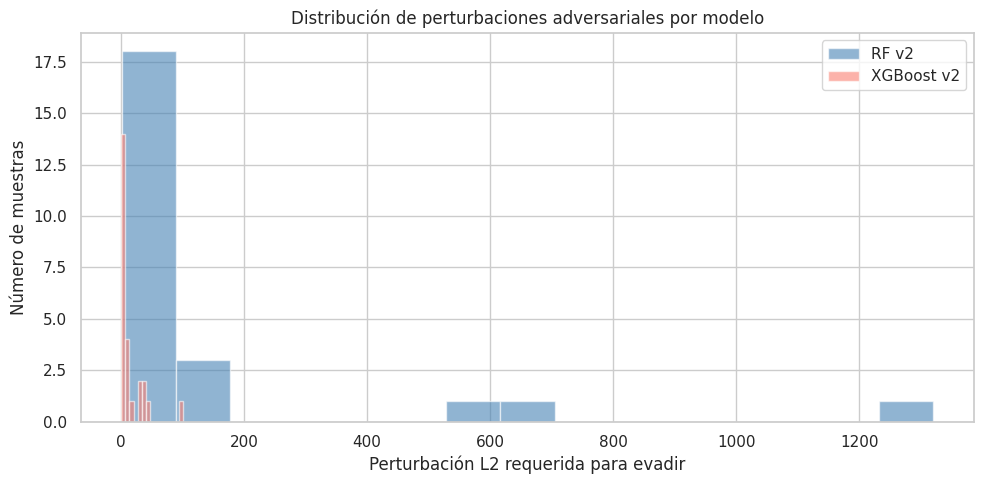

In [8]:
# Histograma de L2 — distribución de perturbaciones por modelo
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(results_rf['l2_per_sample'], bins=15, alpha=0.6, label='RF v2', color='steelblue')
ax.hist(results_xgb['l2_per_sample'], bins=15, alpha=0.6, label='XGBoost v2', color='salmon')
ax.set_xlabel('Perturbación L2 requerida para evadir')
ax.set_ylabel('Número de muestras')
ax.set_title('Distribución de perturbaciones adversariales por modelo')
ax.legend()
plt.tight_layout()
plt.show()

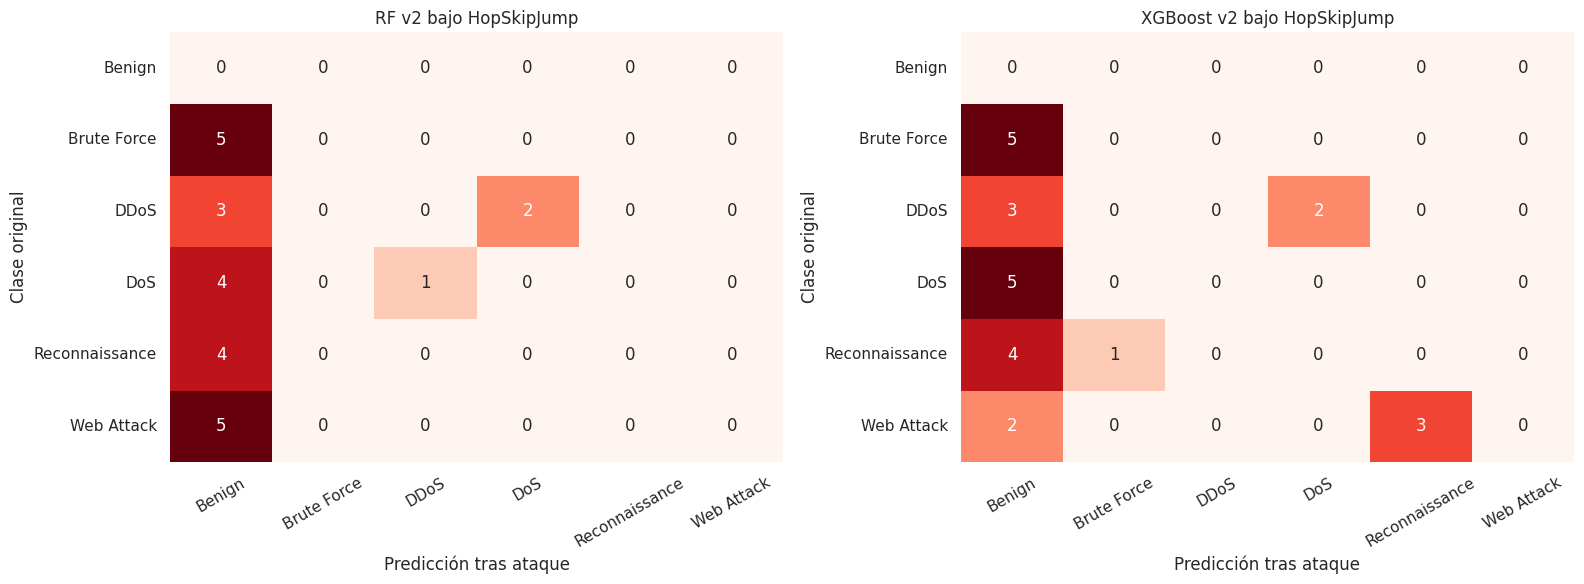

In [9]:
# Confusion matrix: clase original → clase predicha bajo ataque
def adv_cm_plot(results, ax, title):
    true = results['true_str']
    pred = results['pred_adv_str']
    cm = confusion_matrix(true, pred, labels=classes)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
                xticklabels=classes, yticklabels=classes, ax=ax, cbar=False)
    ax.set_title(title)
    ax.set_xlabel('Predicción tras ataque')
    ax.set_ylabel('Clase original')
    ax.tick_params(axis='x', rotation=30)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
adv_cm_plot(results_rf, axes[0], 'RF v2 bajo HopSkipJump')
adv_cm_plot(results_xgb, axes[1], 'XGBoost v2 bajo HopSkipJump')
plt.tight_layout()
plt.show()

## 7. Persistencia de resultados

Guardamos métricas en `logs/art_evasion_v2.json` para que el dashboard
o un futuro tab "Adversarial" del Streamlit las pueda consumir.

In [10]:
# Solo guardamos métricas escalares + serializables (sin arrays numpy ni X_adv)
def serializable(r):
    return {k: v for k, v in r.items() if k not in ('X_adv',)}

payload = {
    'attack': 'HopSkipJump',
    'norm': 'L2',
    'targeted': False,
    'n_per_class': 5,
    'classes': classes,
    'rf_v2':       serializable(results_rf),
    'xgboost_v2':  serializable(results_xgb),
}
with open(RESULT_PATH, 'w') as f:
    json.dump(payload, f, indent=2, default=str)
print(f"Escrito {RESULT_PATH} ({os.path.getsize(RESULT_PATH)/1024:.1f} KB)")

Escrito /run/media/keppler-exe/KINGSTON/Laboratorio-MLCyber/logs/art_evasion_v2.json (3.4 KB)


## 8. Caveats — para que el alumno entienda los límites

**Lo que este notebook NO demuestra**:

1. **Las perturbaciones son matemáticas, no realizables**. HopSkipJump
   modifica directamente las 47 features del flujo (ej: `Flow_IAT_Std`).
   En la realidad, esas features las calcula CICFlowMeter desde el
   tráfico real — el atacante NO puede "elegir" un valor de
   `Bwd_Packet_Length_Mean` arbitrario.
2. **Para un ataque real**: el atacante debe modificar el **tráfico
   generador** (paquetes, timing, payload) y luego *esperar* a que el
   feature extractor produzca features que evadan. Eso es un
   **problem-space attack** — fuera del scope de este lab.
3. **El modelo de amenaza es de "informed insider"**: el atacante puede
   consultar el modelo libremente. En producción, las APIs tienen rate
   limit (60 req/min en este lab) que dificultan reconnaissance.

**Por qué igual vale el ejercicio**:

- Demuestra que F1-macro alto ≠ modelo robusto.
- Justifica por qué el lab tiene **dos detectores en paralelo** (ML +
  Suricata): cuando uno falla, el otro suele atrapar.
- Introduce ART como toolkit para investigación adversarial,
  abriendo el camino a ataques más sofisticados (PGD, Carlini-Wagner)
  y defensas (adversarial training).

**Próximo paso (notebook 08)**: cerrar el ciclo del lab — cargar v2
desde Python, predecir, comparar contra el ML API en runtime para
confirmar que el deploy funciona end-to-end.